In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from torchvision.ops import box_area
import imblearn
from collections import Counter
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift, HighPassFilter

In [2]:
#lab_df = pd.read_csv('wf_labelled_data.csv')
lab_df = pd.read_csv('../Downloads/data-2022-08-01.csv')
labeler_root = 'GitHub/audio_labeller/www'
labeler_list = [l for l in os.listdir(labeler_root) if l not in ['tmp', 'JS']]
labeler_list

['davidfunosas',
 'hhussey3',
 'irishwildlifesounds',
 'markshorten',
 'mcauchoixxx']

In [3]:
lab_prefix = [v.split('@')[0] for v in lab_df.labeler]
lab_df['lab_folder'] = [l if l in labeler_list else 'tmp' for l in lab_prefix]

In [4]:
audio_paths = [os.path.join('wf_data_clips', r.file_name)
               for i, r in lab_df.iterrows()]
audio_paths_exists = [os.path.exists(p) for p in audio_paths]
# do they all exist
np.mean(audio_paths_exists)


0.9953682260305697

In [5]:
pop_class_idx = lab_df.class_label.value_counts()
pop_class_idx

Anthropogenic Noise       433
Blackbird                 269
chaffinch                 151
Bird - Cannot Identify    136
Wren                      123
                         ... 
Skylark                     1
Curlew                      1
mallard                     1
sedge warbler               1
jackdaw                     1
Name: class_label, Length: 63, dtype: int64

In [6]:
idx_lower   = pop_class_idx.index.str.lower()
has_noise    = idx_lower.str.endswith("noise")
unidentified = idx_lower.str.endswith("cannot identify")
pop_classes = pop_class_idx[~np.logical_or(has_noise, unidentified)]
pop_classes = pop_classes[pop_classes >=50].index.str.lower().to_list()
pop_classes

['blackbird',
 'chaffinch',
 'wren',
 'meadow pipit',
 'linnet',
 'rook',
 'wren',
 'robin',
 'yellowhammer']

In [7]:
df = lab_df[audio_paths_exists].copy()

In [8]:
df.class_label = df.class_label.str.lower()

In [9]:
df_popclasses = df[df.class_label.isin(pop_classes)]

In [10]:
df_popclasses

,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,labeler,id,lab_folder
7,10/06/2022 13:55,RICHFIELDM1_20220413_133400_start_0_14.wav,11.404630,14.476576,3.373835,9.011562,wren,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,1,tmp
9,31/05/2022 12:57,RICHFIELDM1_20220413_133400_start_3_2.wav,-0.015440,2.568687,2.523235,9.903113,wren,song,1.00,NaN,djkelly@tcd.ie,1,tmp
10,31/05/2022 12:58,RICHFIELDM1_20220413_133400_start_3_2.wav,11.319712,15.018204,2.617246,9.809102,wren,song,1.00,NaN,djkelly@tcd.ie,1,tmp
11,31/05/2022 12:58,RICHFIELDM1_20220413_133400_start_3_2.wav,-0.018204,2.476029,3.275324,9.433057,wren,song,1.00,NaN,djkelly@tcd.ie,1,tmp
12,31/05/2022 12:58,RICHFIELDM1_20220413_133400_start_3_2.wav,0.015446,2.486324,2.993291,9.856108,wren,song,1.00,NaN,djkelly@tcd.ie,1,tmp
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2147,15/08/2022 19:49,TEEVURCHER_20220530_183500_start_3_44.wav,11.411572,13.899611,1.193899,4.239718,blackbird,NaN,1.00,NaN,markshorten@icloud.com,1,markshorten
2148,15/08/2022 19:49,TEEVURCHER_20220530_183500_start_3_58.wav,2.083756,4.459973,1.428193,6.676373,robin,NaN,0.70,NaN,markshorten@icloud.com,1,markshorten
2152,15/08/2022 19:51,TEEVURCHER_20220530_190500_start_1_52.wav,5.252045,6.370265,0.865888,3.771131,blackbird,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2153,15/08/2022 19:51,TEEVURCHER_20220530_190500_start_1_52.wav,10.442449,13.470960,1.287617,3.630554,blackbird,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten


In [11]:
def bbox_fn(x):
    bboxes = torch.tensor(
        x[['start_time', 'start_freq', 'end_time', 'end_freq']].values)
    return box_area(bboxes).sum().item()


In [12]:
df_bboxes = df_popclasses.groupby(
    ["file_name", "class_label"]).apply(bbox_fn).reset_index()
df_bboxes.columns = df_bboxes.columns[:-1].to_list() + ["bbox_sum"]

df_bboxes = df_bboxes.sort_values(
    by=['file_name', 'bbox_sum'])  # , drop_duplicates()
df_singlelabs = df_bboxes.drop_duplicates("file_name", keep="last")


In [13]:
df_singlelabs

,file_name,class_label,bbox_sum
0,CARNSOREMET_20220427_153300_start_3_44.wav,meadow pipit,17.871229
2,CARNSOREMET_20220427_154300_start_2_34.wav,meadow pipit,24.259819
3,CARNSOREMET_20220427_160300_start_1_24.wav,blackbird,1.937444
4,CARNSOREMET_20220427_160300_start_1_38.wav,blackbird,1.883127
5,CARNSOREMET_20220427_160300_start_3_16.wav,wren,16.062182
...,...,...,...
576,TEEVURCHER_20220530_183500_start_3_30.wav,robin,19.667733
577,TEEVURCHER_20220530_183500_start_3_44.wav,blackbird,19.715765
578,TEEVURCHER_20220530_183500_start_3_58.wav,robin,12.470815
579,TEEVURCHER_20220530_190500_start_1_52.wav,blackbird,10.344314


In [14]:
pop_classes = np.sort(df_singlelabs.class_label.unique())
pop_classes

array(['blackbird', 'chaffinch', 'linnet', 'meadow pipit', 'robin',
       'rook', 'wren', 'yellowhammer'], dtype=object)

In [15]:
#filenames = tf.io.gfile.glob(str(data_dir) + '/*/*')
wav_paths = [os.path.join('wf_data_clips', r.file_name)
             for i, r in df_singlelabs.iterrows()]
filenames = tf.convert_to_tensor(np.unique(np.array(wav_paths)))
#filenames = tf.random.shuffle(filenames)
num_samples = len(filenames)
print('Number of total examples:', num_samples)
# print('Number of examples per label:',
#      len(tf.io.gfile.listdir(str(data_dir/commands[0]))))
print('Example file tensor:', filenames[0])


Number of total examples: 430
Example file tensor: tf.Tensor(b'wf_data_clips\\CARNSOREMET_20220427_153300_start_3_44.wav', shape=(), dtype=string)


In [16]:
filenames = [f.numpy().decode().replace('\\', '/') for f in filenames]
#filenames = [f.replace('/', os.path.sep) for f in filenames]
filenames = [f for f in filenames if os.path.exists(f)]
filenames[:5]

['wf_data_clips/CARNSOREMET_20220427_153300_start_3_44.wav',
 'wf_data_clips/CARNSOREMET_20220427_154300_start_2_34.wav',
 'wf_data_clips/CARNSOREMET_20220427_160300_start_1_24.wav',
 'wf_data_clips/CARNSOREMET_20220427_160300_start_1_38.wav',
 'wf_data_clips/CARNSOREMET_20220427_160300_start_3_16.wav']

In [17]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
batch_size = 32
EPOCHS = 20

In [18]:
from tf_helpers import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, top_k_accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from math import prod


In [19]:
filename_df = pd.DataFrame({'name': filenames,
                            'label': df_singlelabs.class_label.values})

In [20]:
#filenames   = tf.random.shuffle(filenames)
#all_labs    = [get_label(y).numpy().decode() for y in filenames]


# , stratify=filename_df[['label']])
train, test = train_test_split(filename_df, test_size=0.2, stratify=filename_df[['label']])

In [21]:
augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(min_fraction=-0.5, max_fraction=0.5, p=0.5),
])

In [77]:
#augment = Compose([HighPassFilter()])
hpass = HighPassFilter(max_cutoff_freq=4000)

In [78]:
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

In [93]:
choices = ['Mod']
categories = pop_classes

def get_labname(x):
    return x, filename_df[filename_df.name == x].label

def get_waveform_and_label(x_tuple):
    file_path, label = x_tuple[0], x_tuple[1]
    audio_binary = tf.io.read_file(file_path)
    waveform, sr = decode_audio(audio_binary)
    return waveform[:15*sr], label

def get_spectrogram_and_label_id(x_tuple, choices=['Mod'], categories=pop_classes, req_width=400, single_to_rgb=False, resize=1, spec_norm=False):
    audio, label = x_tuple[0], x_tuple[1]
    #spectrogram = get_complex_spectrogram(audio)
    # print(dir(audio))
    aud, sr = audio, 44100
    #aud, sr      = audio
    complex_spec = gen_complex_spec(aud, sr)
    multi_spec = multi_spec_stack(complex_spec, choices)
    multi_spec = multi_spec_post(multi_spec, req_width, spec_norm, resize)
    if single_to_rgb:
        multi_spec = tf.concat([multi_spec, multi_spec, multi_spec], axis=-1)
        multi_spec = tf.stack(multi_spec)
    #multi_spec = complex_spec
    spec_shape = tf.shape(multi_spec)
    if resize > 1:
        multi_spec = tf.image.resize(
            multi_spec, [spec_shape[0]//resize, spec_shape[1]//resize])
    label_id = tf.argmax(label == categories)
    return multi_spec, label_id

def augment_audio(x_tuple):
    audio, label = x_tuple[0], x_tuple[1]
    audio = augment(audio, sample_rate=44100)
    # Augment/transform/perturb the audio data
    return audio, label

def preprocess_dataset(df, aug = False):
    t_ds = tf.data.Dataset.from_tensor_slices(df)
    wave_ds = t_ds.map(get_waveform_and_label, num_parallel_calls=AUTOTUNE)
    if aug == True:
        wave_ds = wave_ds.map(lambda x, y: (hpass(x.astype('float32'), sample_rate=44100), y))
    #wave_ds = wave_ds.map(lambda x,y: augment_audio((x,y)), num_parallel_calls=AUTOTUNE)
    output_ds = wave_ds.map(lambda x, y: get_spectrogram_and_label_id(
        (x, y)),  num_parallel_calls=AUTOTUNE)
    return output_ds

In [83]:
processed_ds = preprocess_dataset(filename_df, aug = True)

In [84]:
inputs  = [x for x,_ in processed_ds]
targets = [y for _,y in processed_ds]

inputs  = np.array(inputs)
targets = np.array(targets)

In [85]:
from sklearn.model_selection import KFold

In [86]:
# Merge inputs and targets
#inputs = np.concatenate((input_train, input_test), axis=0)
#targets = np.concatenate((target_train, target_test), axis=0)

# Define the K-fold Cross Validator
kfold = KFold(n_splits=10, shuffle=True)

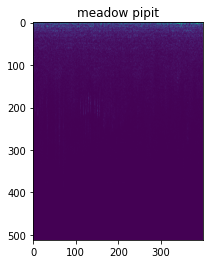

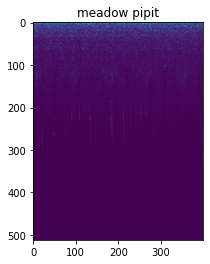

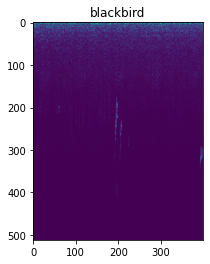

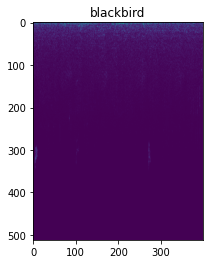

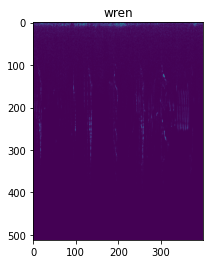

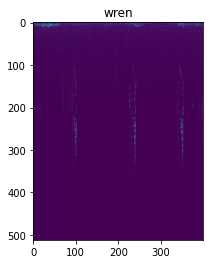

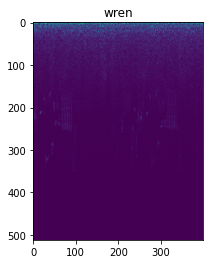

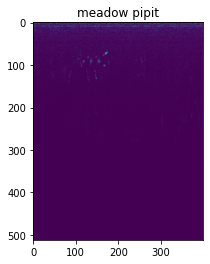

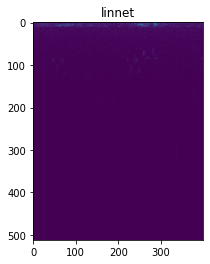

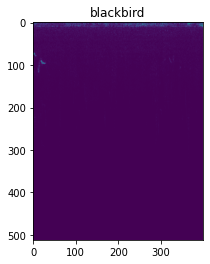

In [87]:
n_plots = 5
#subplot(r,c) provide the no. of rows and columns
#f, axarr = plt.subplots(1, n_plots) 

#i = 0
for spec, lab in processed_ds.take(10):
    inp_shape = spec.shape
    plt.figure()
    plt.imshow(spec)
    plt.title(pop_classes[lab])
    #axarr[i].imshow(spec)
    #i += 1

In [88]:
# K-fold Cross Validation model evaluation
acc_per_fold  = []
loss_per_fold = []
fold_no = 1
for train, test in kfold.split(inputs, targets):
  #print(train)
  #print(test)
  # Define the model architecture
  model = main_cnn(inp_shape, num_classes=len(categories))

  # Generate a print
  print('------------------------------------------------------------------------')
  print(f'Training for fold {fold_no} ...')

  # Fit data to model
  history = model.fit(inputs[train], targets[train],
              batch_size=batch_size,
              epochs=EPOCHS,
              verbose=1)

  # Generate generalization metrics
  scores = model.evaluate(inputs[test], targets[test], verbose=0)
  print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])

  # Increase fold number
  fold_no = fold_no + 1

------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/20
13/13 [==============================] - 18s 1s/step - loss: 2.1137 - accuracy: 0.2455
Epoch 2/20
13/13 [==============================] - 20s 2s/step - loss: 1.9725 - accuracy: 0.3385
Epoch 3/20
13/13 [==============================] - 23s 2s/step - loss: 1.8389 - accuracy: 0.4186
Epoch 4/20
13/13 [==============================] - 25s 2s/step - loss: 1.6799 - accuracy: 0.4755
Epoch 5/20
13/13 [==============================] - 24s 2s/step - loss: 1.5610 - accuracy: 0.5116
Epoch 6/20
13/13 [==============================] - 25s 2s/step - loss: 1.4748 - accuracy: 0.5401
Epoch 7/20
13/13 [==============================] - 22s 2s/step - loss: 1.3808 - accuracy: 0.5607
Epoch 8/20
13/13 [==============================] - 25s 2s/step - loss: 1.2982 - accuracy: 0.5917
Epoch 9/20
13/13 [==============================] - 23s 2s/step - loss: 1.2221 - accuracy: 0.6305
Epoch 10/20
13/13 [==

In [89]:
# == Provide average scores ==
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 1.5549654960632324 - Accuracy: 60.4651153087616%
------------------------------------------------------------------------
> Fold 2 - Loss: 1.2103723287582397 - Accuracy: 65.11628031730652%
------------------------------------------------------------------------
> Fold 3 - Loss: 1.4394612312316895 - Accuracy: 53.48837375640869%
------------------------------------------------------------------------
> Fold 4 - Loss: 1.1946967840194702 - Accuracy: 65.11628031730652%
------------------------------------------------------------------------
> Fold 5 - Loss: 1.5834251642227173 - Accuracy: 60.4651153087616%
------------------------------------------------------------------------
> Fold 6 - Loss: 1.4041637182235718 - Accuracy: 53.48837375640869%
------------------------------------------------------------------------
>

In [96]:
processed_ds = preprocess_dataset(filename_df, aug = False)
inputs  = [x for x,_ in processed_ds]
targets = [y for _,y in processed_ds]

inputs  = np.array(inputs)
targets = np.array(targets)
kfold = KFold(n_splits=5, shuffle=True)

In [98]:
# K-fold Cross Validation model evaluation
acc_per_fold  = []
loss_per_fold = []
fold_no = 1
for train, test in kfold.split(inputs, targets):
  #print(train)
  #print(test)
  # Define the model architecture
  model = main_cnn(inp_shape, num_classes=len(categories))

  # Generate a print
  print('------------------------------------------------------------------------')
  print(f'Training for fold {fold_no} ...')

  # Fit data to model
  history = model.fit(inputs[train], targets[train],
              batch_size=batch_size,
              epochs=EPOCHS,
              verbose=1)

  # Generate generalization metrics
  scores = model.evaluate(inputs[test], targets[test], verbose=0)
  print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])

  # Increase fold number
  fold_no = fold_no + 1

------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/20
11/11 [==============================] - 19s 2s/step - loss: 2.1040 - accuracy: 0.1221
Epoch 2/20
11/11 [==============================] - 18s 2s/step - loss: 2.0003 - accuracy: 0.2762
Epoch 3/20
11/11 [==============================] - 18s 2s/step - loss: 1.8905 - accuracy: 0.3634
Epoch 4/20
11/11 [==============================] - 17s 2s/step - loss: 1.7512 - accuracy: 0.4506
Epoch 5/20
11/11 [==============================] - 17s 2s/step - loss: 1.6250 - accuracy: 0.4680
Epoch 6/20
11/11 [==============================] - 17s 2s/step - loss: 1.5076 - accuracy: 0.5233
Epoch 7/20
11/11 [==============================] - 16s 1s/step - loss: 1.4209 - accuracy: 0.5349
Epoch 8/20
11/11 [==============================] - 17s 1s/step - loss: 1.3502 - accuracy: 0.5640
Epoch 9/20
11/11 [==============================] - 20s 2s/step - loss: 1.3081 - accuracy: 0.5756
Epoch 10/20
11/11 [==

In [99]:
# == Provide average scores ==
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 1.2914297580718994 - Accuracy: 67.44186282157898%
------------------------------------------------------------------------
> Fold 2 - Loss: 1.5347692966461182 - Accuracy: 55.81395626068115%
------------------------------------------------------------------------
> Fold 3 - Loss: 1.8456428050994873 - Accuracy: 65.11628031730652%
------------------------------------------------------------------------
> Fold 4 - Loss: 1.580503225326538 - Accuracy: 58.139532804489136%
------------------------------------------------------------------------
> Fold 5 - Loss: 1.4904571771621704 - Accuracy: 60.4651153087616%
------------------------------------------------------------------------
Average scores for all folds:
> Accuracy: 61.39534950256348 (+- 4.313311442324651)
> Loss: 1.5485604524612426
------------------------------